# Correlation analysis: HR features vs. Frustrated

Before deciding which heart-rate features to actually use in `logistic_regression_training.ipynb`
and `ANN_training.ipynb`, we checked how each of the 6 HR statistics correlates with the binary
frustration label (`Frustrated_binary`, threshold = 3 on the 0--8 scale).

We did this twice: once on the raw HR features as they appear in `HR_data.csv`, and once on the
per-individual normalized version (each feature z-scored within each person), since that's what
the model pipelines actually train on. For each version we plot a correlation heatmap and a ranked
bar chart of each feature's correlation with `Frustrated`. The two rankings ended up looking quite
different, which turned out to matter for which features we kept.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

df = pd.read_csv("HR_data.csv", index_col=0)

threshold = 3  # same threshold as the model notebooks
df["Frustrated_binary"] = (df["Frustrated"] >= threshold).astype(int)

hr_feature_cols = ["HR_Mean", "HR_Median", "HR_std", "HR_Min", "HR_Max", "HR_AUC"]
df.head()

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort,Frustrated_binary
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1,0
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1,1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1,0
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1,0
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1,1


## 1. Raw correlation analysis

The HR features here are exactly as measured (not normalized in any way).

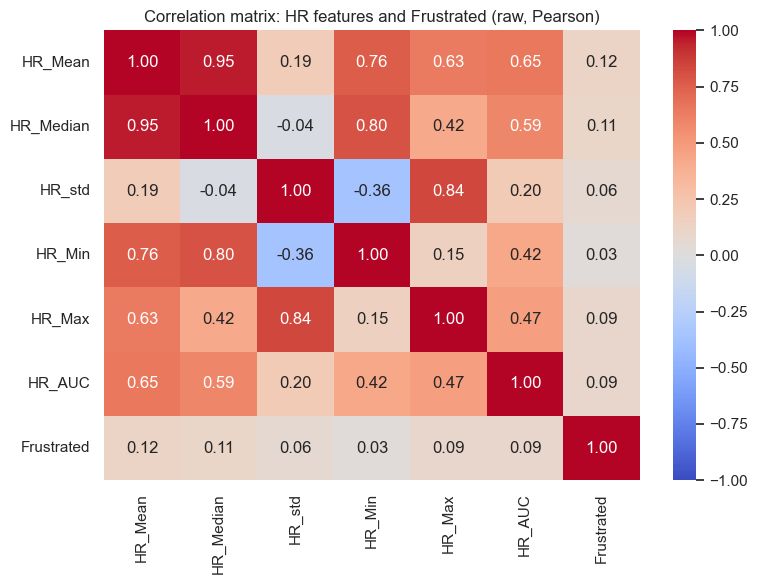

In [2]:
corr_raw = df[hr_feature_cols + ["Frustrated"]].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix: HR features and Frustrated (raw, Pearson)")
plt.tight_layout()
plt.show()

Raw Spearman correlation with Frustrated (sorted strongest to weakest):
HR_Max       0.180681
HR_std       0.179403
HR_AUC       0.168586
HR_Mean      0.123036
HR_Median    0.089125
HR_Min      -0.002497
dtype: float64


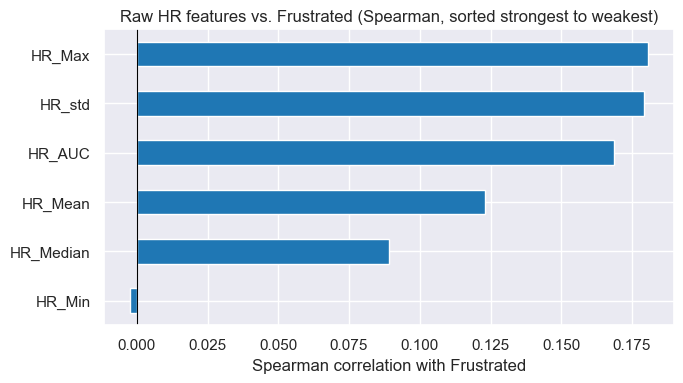

In [3]:
raw_corr = pd.Series(
    {col: spearmanr(df[col], df["Frustrated"]).correlation for col in hr_feature_cols}
).sort_values(ascending=False)

print("Raw Spearman correlation with Frustrated (sorted strongest to weakest):")
print(raw_corr)

plt.figure(figsize=(7, 4))
raw_corr.plot(kind="barh", color="tab:blue")
plt.gca().invert_yaxis()
plt.xlabel("Spearman correlation with Frustrated")
plt.title("Raw HR features vs. Frustrated (Spearman, sorted strongest to weakest)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

Going only by these raw correlations, `HR_Max`, `HR_std`, `HR_AUC` and `HR_Mean` look like the
strongest features (`HR_Max` ~0.18, `HR_std` ~0.18, `HR_AUC` ~0.17, `HR_Mean` ~0.12), with
`HR_Median` (~0.09) and `HR_Min` (~0.00) close to noise. That was our first impression, before
normalizing per individual below.

## 2. Per-individual normalized correlation analysis

Resting heart rate and heart-rate variability differ a lot from person to person, so the raw
ranking above is partly just picking up on who naturally runs higher or lower. To see the
within-person signal instead, we z-score each HR feature per individual (subtract that person's
own mean, divide by their own std) and redo the same analysis. This is also the version of the
features that the logistic regression and ANN pipelines actually train on.

In [4]:
df_norm = df.copy()
for col in hr_feature_cols:
    df_norm[col] = df.groupby("Individual")[col].transform(lambda s: (s - s.mean()) / s.std())

df_norm[hr_feature_cols].describe()

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC
count,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02
mean,6.079793e-17,-1.059999e-15,-3.700743e-17,1.073216e-15,-5.709718e-16,-6.079793e-17
std,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01
min,-2.090416e+00,-2.320427e+00,-1.561129e+00,-2.182425e+00,-1.751144e+00,-1.571144e+00
25%,-7.280204e-01,-7.704507e-01,-6.933782e-01,-6.394762e-01,-7.559462e-01,-6.944055e-01
50%,-2.775503e-02,-8.617163e-02,-3.165731e-01,-2.825492e-02,-2.086793e-01,-2.577854e-01
75%,6.248084e-01,6.679727e-01,5.324870e-01,7.243773e-01,5.103417e-01,5.597943e-01
max,2.091565e+00,2.416027e+00,2.897812e+00,2.161078e+00,2.546851e+00,2.937623e+00


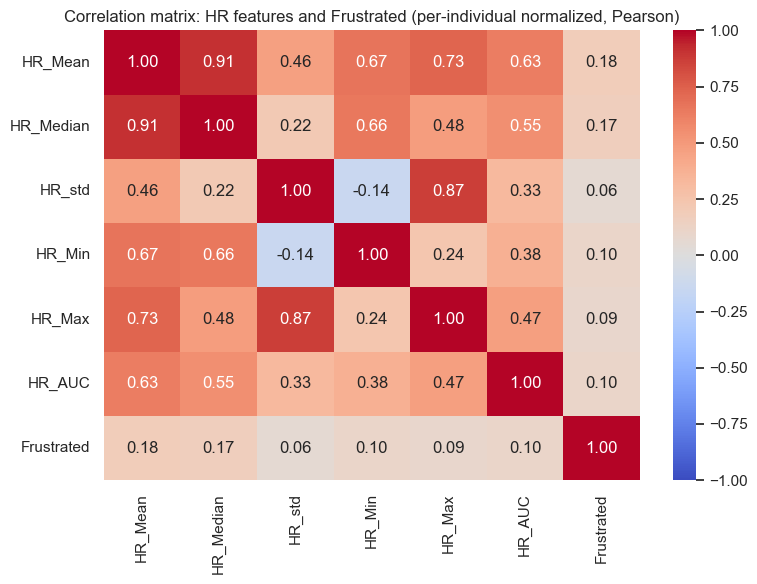

In [5]:
corr_norm = df_norm[hr_feature_cols + ["Frustrated"]].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_norm, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix: HR features and Frustrated (per-individual normalized, Pearson)")
plt.tight_layout()
plt.show()

Per-individual normalized Spearman correlation with Frustrated (sorted strongest to weakest):
HR_Mean      0.175732
HR_Median    0.157491
HR_AUC       0.145844
HR_Max       0.107842
HR_std       0.086632
HR_Min       0.066574
dtype: float64


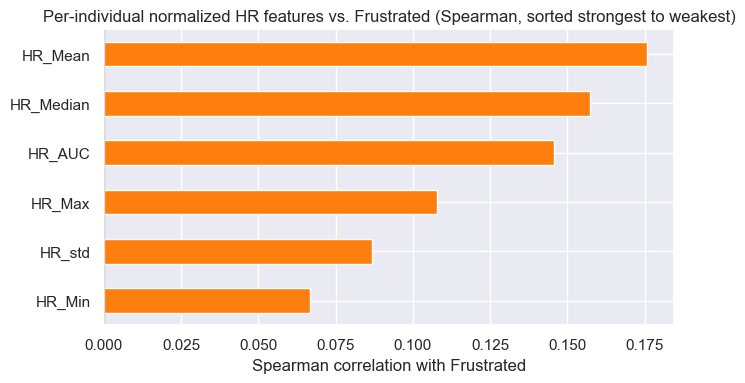

In [6]:
norm_corr = pd.Series(
    {col: spearmanr(df_norm[col], df_norm["Frustrated"]).correlation for col in hr_feature_cols}
).sort_values(ascending=False)

print("Per-individual normalized Spearman correlation with Frustrated (sorted strongest to weakest):")
print(norm_corr)

plt.figure(figsize=(7, 4))
norm_corr.plot(kind="barh", color="tab:orange")
plt.gca().invert_yaxis()
plt.xlabel("Spearman correlation with Frustrated")
plt.title("Per-individual normalized HR features vs. Frustrated (Spearman, sorted strongest to weakest)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 3. Why the rankings flip

Looking back at Section 1, the raw correlations mostly pick up on differences *between* people:
someone with a naturally higher resting heart rate, or more heart-rate variability in general, will
tend to have a higher raw `HR_Max`/`HR_std`/`HR_AUC`, and may also just happen to report more
frustration on average, even if the two aren't really connected for that person.

Normalizing per individual (Section 2) removes that between-person baseline and leaves the
within-person signal: for a given person, is this particular measurement higher or lower than
their own normal level, and does that line up with their own frustration? That's the version that
should still hold for a new, unseen person (given a short calibration period), and it's what the
logistic regression and ANN pipelines actually train on.

Once we normalized, the ranking flipped more than we expected: `HR_Mean` and `HR_Median` moved to
the top, while `HR_Max` and `HR_std`, the strongest features in the raw ranking, dropped to the
weakest. `HR_Min` stayed weak either way.

Based on this, we settled on the same fixed set of 5 HR features for both models, `HR_Mean`,
`HR_Median`, `HR_std`, `HR_Max`, `HR_AUC`, dropping `HR_Min`, plus one-hot encoded `Phase` and
`Round`. That's the feature set behind the results in `model_comparison.ipynb`.